In [1]:
import sys
print(sys.executable)

d:\anaconda3\envs\dl\python.exe


In [ ]:
%load_ext autoreload
%autoreload 2

# 1. 导包+全局变量

In [16]:
import GetData
import Model
import Train

import torch 
from torch.utils.data import TensorDataset,DataLoader
import numpy as np

import matplotlib.pyplot as plt


In [20]:
EPOCHS=300
PRINT_EPOC=20
BATCH_SIZE=256  # 原论文128
lr=2e-4
wd=0

device="cuda:0" if torch.cuda.is_available() else "cpu"
IN_CHANNELS=3
HIDDEN_CHANNELS=128
OUT_CHANNELS=3
RESIDUAL_CHANNELS=32
RESIDUAL_LAYERS=2
NUM_EMBEDDINGS=512    
EMBEDDING_DIM=64
DECAY=0.99
COMMIT_COST=0.25

mean=[0.4914, 0.4822, 0.4465]
std=[0.2470, 0.2435, 0.2616]

# 2. 准备数据

## 2.1 获取加载器+标签字典

In [5]:
train_loader,test_loader=GetData.get_CIFAR(BATCH_SIZE)
cifar10_labels = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 2.2 可视化

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8997625..1.6621895].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3020554..1.9162182].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8192375..1.3605304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9158674..1.9659187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9319725..0.14557327].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9480774..2.115826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.910089

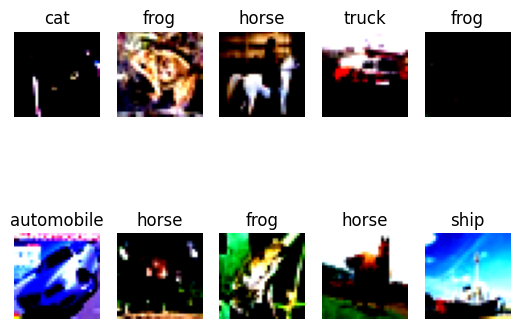

In [6]:
first_train_batch=next(iter(train_loader))
first_test_batch=next(iter(train_loader))

first_train_batch_image=first_train_batch[0][:10].permute(0,2,3,1)
first_train_batch_label=first_train_batch[1][:10]
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(first_train_batch_image[i])
    plt.title(cifar10_labels[first_train_batch_label[i].item()])
    plt.axis("off")
plt.show()

# 3. 训练

In [7]:
init_model=Model.Model(
    IN_CHANNELS,HIDDEN_CHANNELS,OUT_CHANNELS,
    RESIDUAL_CHANNELS,RESIDUAL_LAYERS,
    NUM_EMBEDDINGS,EMBEDDING_DIM,DECAY,COMMIT_COST
)

epoch: 20
reconstruction loss=0.069725240752697
commit loss=0.02403970496594906
total loss=0.09376494579792023
perplexity=273.9536044140625



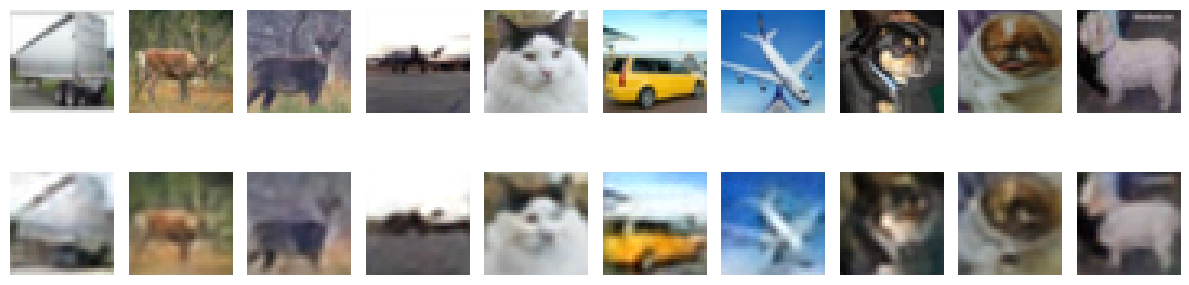

epoch: 40
reconstruction loss=0.0570375408911705
commit loss=0.03182727989077568
total loss=0.08886482083320618
perplexity=410.1496927050781



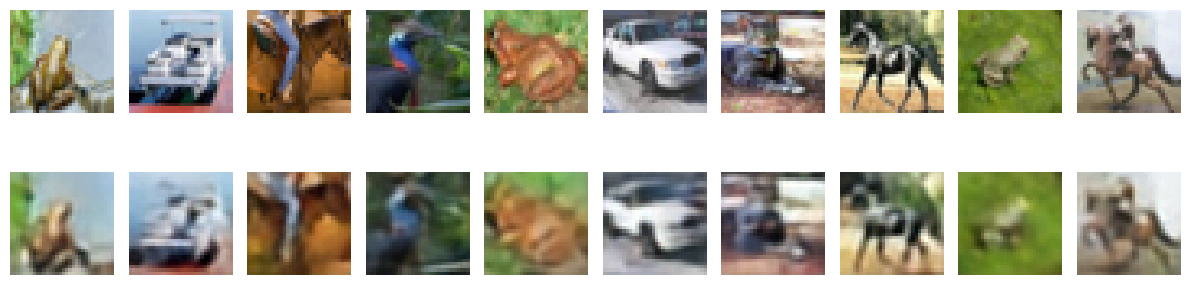

epoch: 60
reconstruction loss=0.055390616694688796
commit loss=0.03606129521250725
total loss=0.09145191175460815
perplexity=404.90648740234377



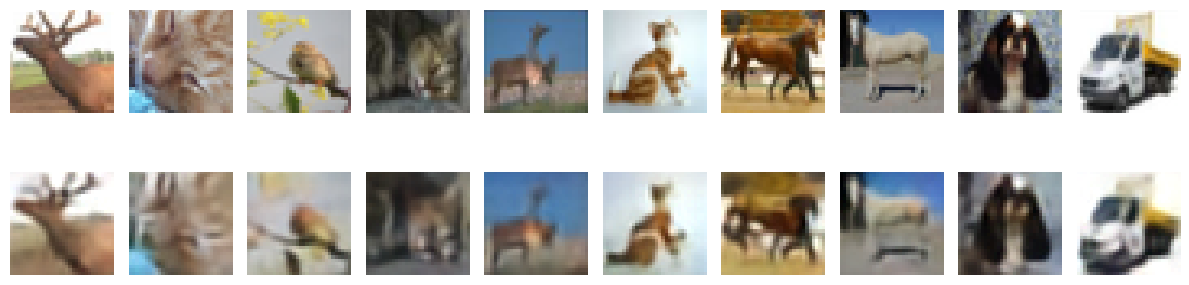

epoch: 80
reconstruction loss=0.05347692612767219
commit loss=0.037793692401647566
total loss=0.09127061868190765
perplexity=406.51849119140627



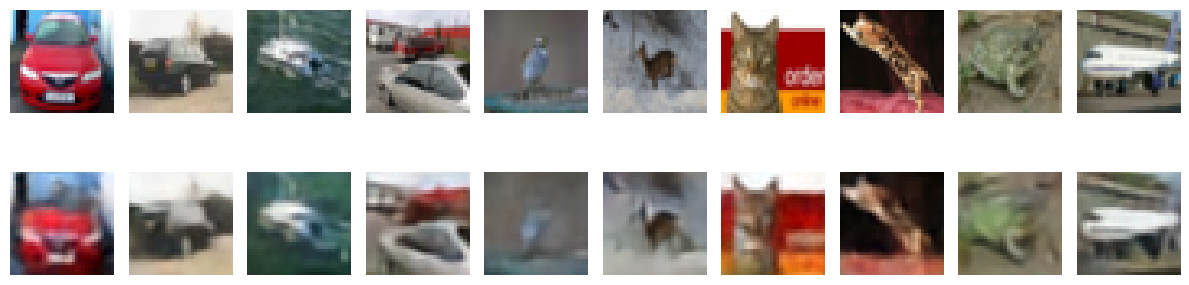

epoch: 100
reconstruction loss=0.053193306374549866
commit loss=0.039059888163805005
total loss=0.09225319422721863
perplexity=405.1955454980469



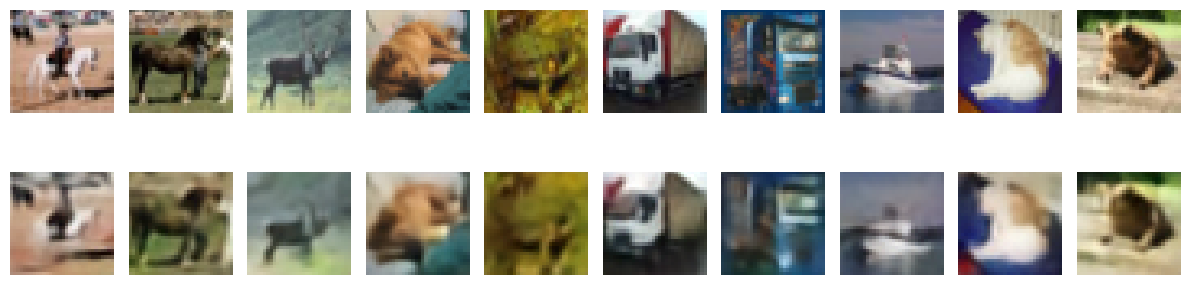

epoch: 120
reconstruction loss=0.05209328839659691
commit loss=0.04014847797513008
total loss=0.0922417665052414
perplexity=406.74200481445314



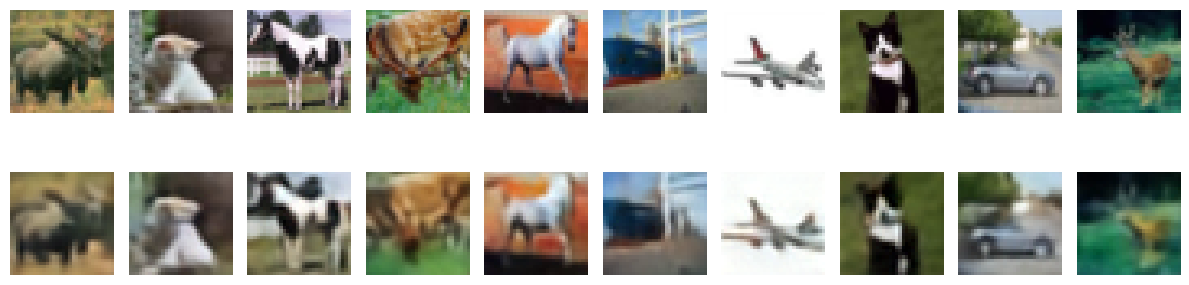

epoch: 140
reconstruction loss=0.052358969053030016
commit loss=0.04039536931395531
total loss=0.0927543383860588
perplexity=406.33457291992187



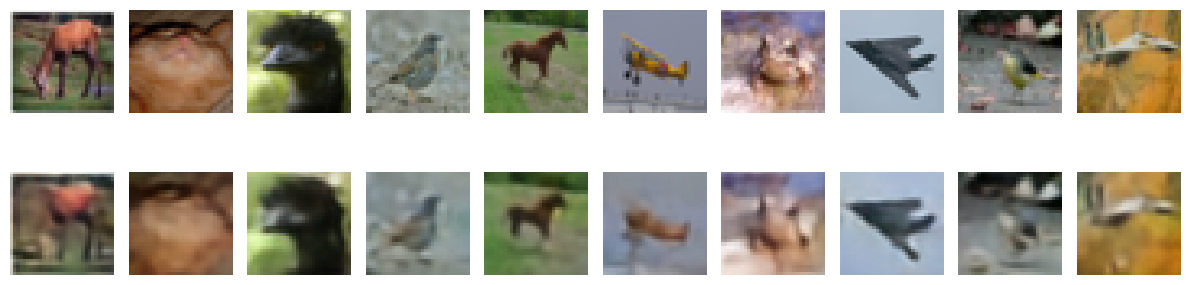

epoch: 160
reconstruction loss=0.05142739288210869
commit loss=0.041792306625843045
total loss=0.0932196991968155
perplexity=407.10703452148437



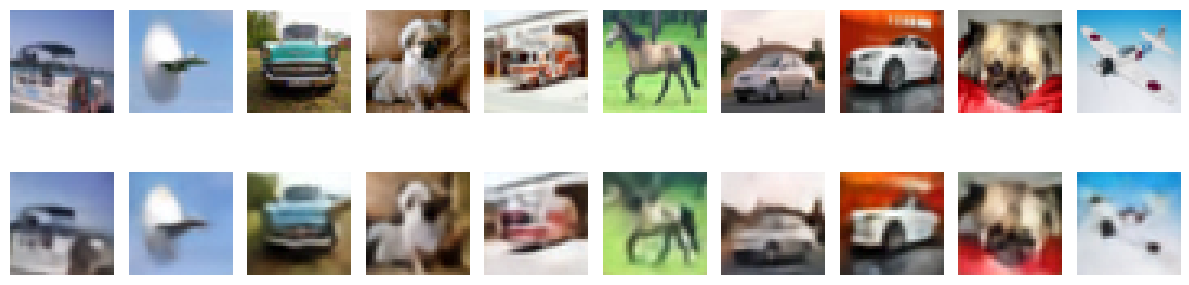

epoch: 180
reconstruction loss=0.051022374482154846
commit loss=0.0423879385972023
total loss=0.09341031298398972
perplexity=407.46459155273436



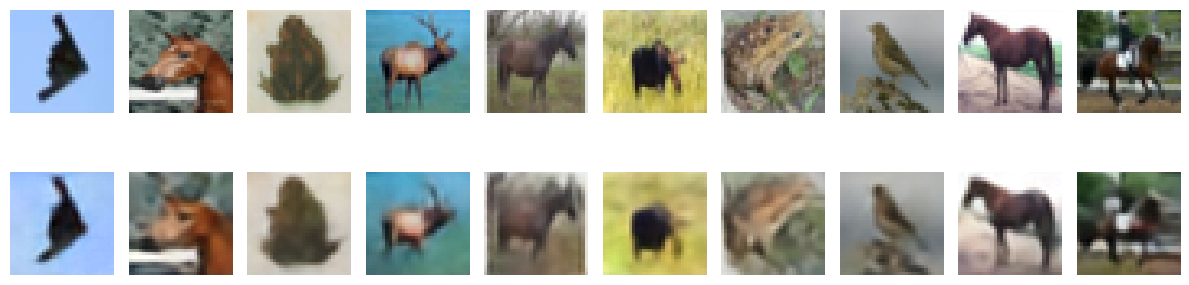

epoch: 200
reconstruction loss=0.050778306111097335
commit loss=0.042789001305103304
total loss=0.09356730748653412
perplexity=407.5820645117187



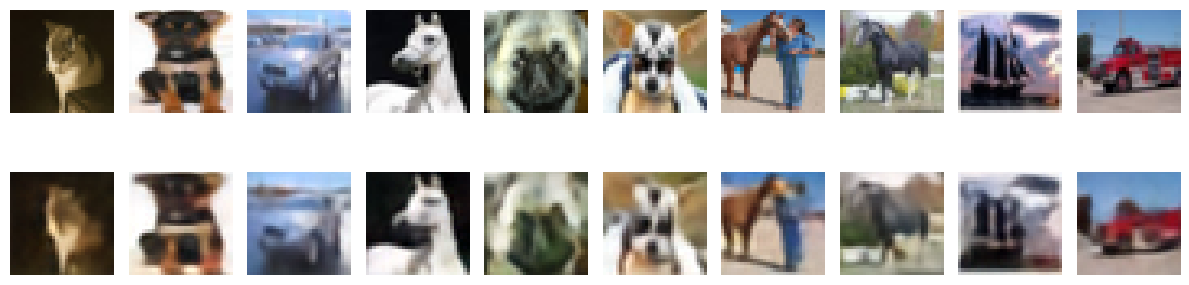

epoch: 220
reconstruction loss=0.05063776753306389
commit loss=0.042974747067689896
total loss=0.09361251465797424
perplexity=407.6964476171875



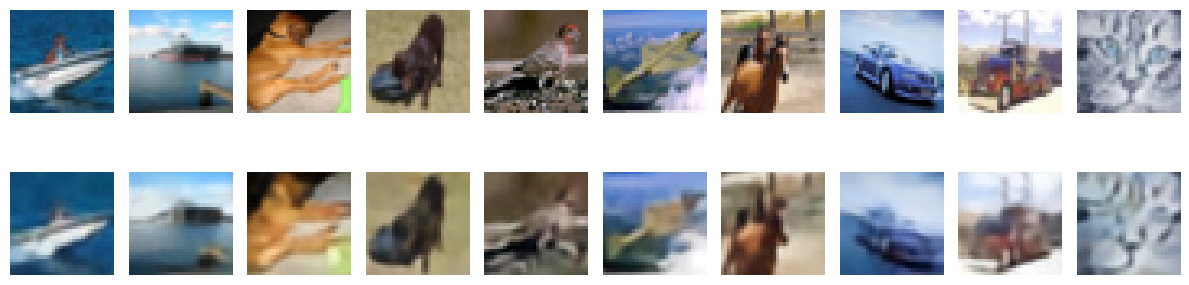

epoch: 240
reconstruction loss=0.05039747646808624
commit loss=0.04336211857795715
total loss=0.09375959479808807
perplexity=407.48340826171875



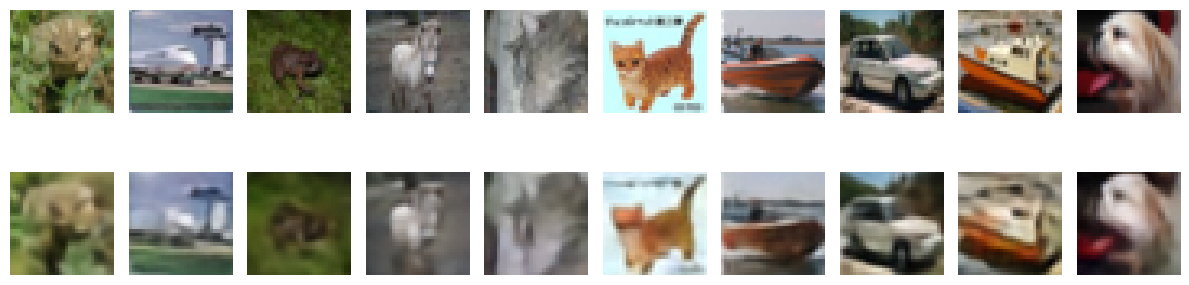

epoch: 260
reconstruction loss=0.050251339069604876
commit loss=0.04360191994547844
total loss=0.09385325901508332
perplexity=407.637967265625



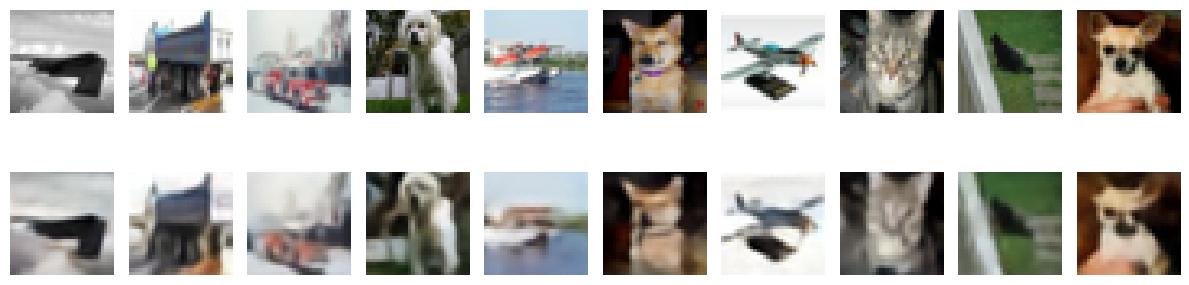

epoch: 280
reconstruction loss=0.05008525593400002
commit loss=0.043793654242753985
total loss=0.09387891034841538
perplexity=407.93921701171877



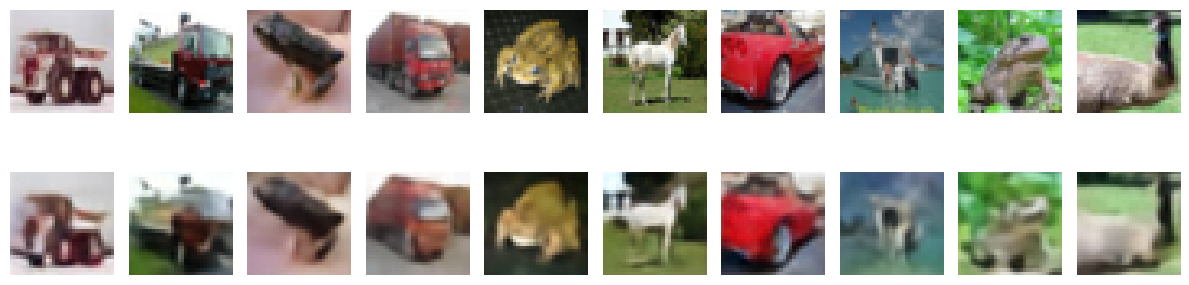

epoch: 300
reconstruction loss=0.050017092772722246
commit loss=0.04387728892683983
total loss=0.09389438183307648
perplexity=407.6453404785156



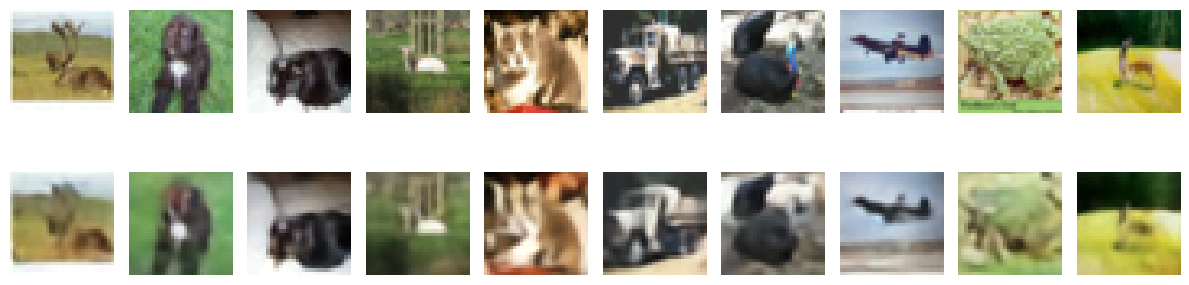

In [ ]:
perplexity_list,loss_list,recon_loss_list,commit_loss_list,best_model=Train.train_pipeline(
    init_model,train_loader,EPOCHS,PRINT_EPOC,lr,wd,device,
    mean,std
)

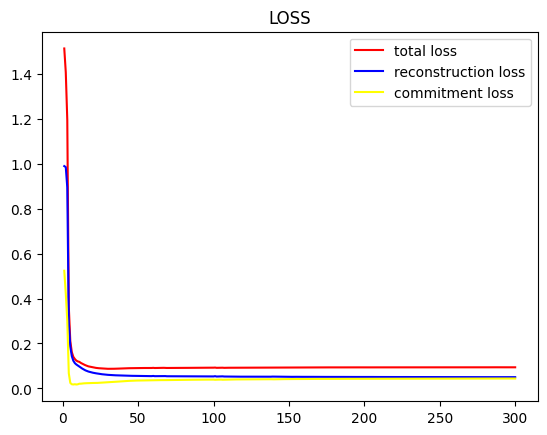

In [9]:
plt.plot(torch.arange(1,EPOCHS+1),loss_list,"red",label="total loss")
plt.plot(torch.arange(1,EPOCHS+1),recon_loss_list,"blue",label="reconstruction loss")
plt.plot(torch.arange(1,EPOCHS+1),commit_loss_list,"yellow",label="commitment loss")

plt.legend()
plt.title("LOSS")
plt.show()

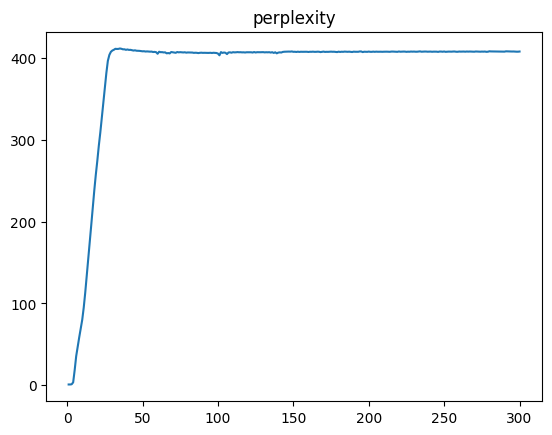

In [10]:
plt.plot(torch.arange(1,EPOCHS+1),perplexity_list)
plt.title("perplexity")
plt.show()

In [11]:
import os

SAVE_DIR = r"..\checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, "best_vqvae_cifar.pt")

torch.save({
    "model_state_dict": best_model.state_dict(),
    "loss_list": loss_list,
    "recon_loss_list": recon_loss_list,
    "commit_loss_list": commit_loss_list,
    "perplexity_list": perplexity_list,
    "best_loss": min(loss_list),
    "config": {
        "IN_CHANNELS": IN_CHANNELS,
        "HIDDEN_CHANNELS": HIDDEN_CHANNELS,
        "OUT_CHANNELS": OUT_CHANNELS,
        "RESIDUAL_CHANNELS": RESIDUAL_CHANNELS,
        "RESIDUAL_LAYERS": RESIDUAL_LAYERS,
        "NUM_EMBEDDINGS": NUM_EMBEDDINGS,
        "EMBEDDING_DIM": EMBEDDING_DIM,
        "DECAY": DECAY,
        "COMMIT_COST": COMMIT_COST,
    },
}, SAVE_PATH)

print(f"best model saved to: {SAVE_PATH}")
print(f"best total loss: {min(loss_list):.6f}")

best model saved to: ..\checkpoints\best_vqvae_cifar.pt
best total loss: 0.087140


# 4. 测试集重建

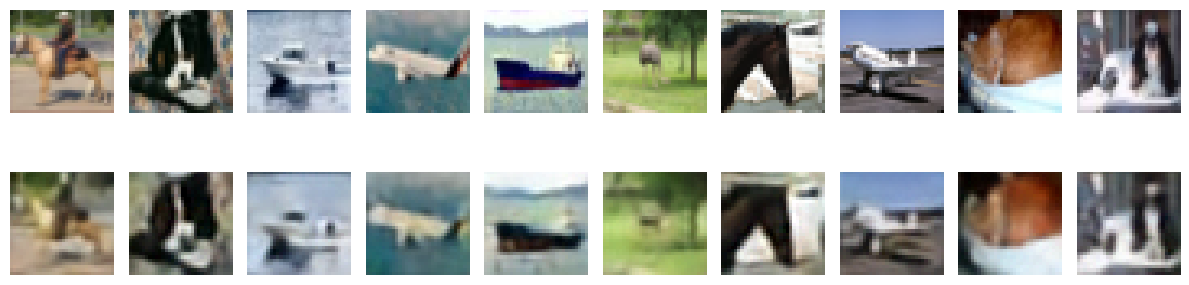

In [ ]:
Train.valid(best_model,test_loader,device,mean,std,1)